In [10]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
username = "Abhiix0"

url = f"https://api.github.com/users/{username}/repos"

response = requests.get(url)

repos = response.json()

print(f"Total repositories fetched: {len(repos)}")

Total repositories fetched: 25


In [5]:
df = pd.DataFrame(repos)

df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,is_template,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch
0,1060685394,R_kgDOPzjGUg,30-Days-Of-React,Abhiix0/30-Days-Of-React,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/30-Days-Of-React,30 Days of React challenge is a step by step ...,True,https://api.github.com/repos/Abhiix0/30-Days-O...,...,False,False,True,all,[],public,0,0,0,master
1,1029715409,R_kgDOPWA10Q,Abhiix0,Abhiix0/Abhiix0,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/Abhiix0,NaN,False,https://api.github.com/repos/Abhiix0/Abhiix0,...,False,False,True,all,[],public,0,0,0,main
2,1174478679,R_kgDORgEfVw,AI-Data-Analyst,Abhiix0/AI-Data-Analyst,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/AI-Data-Analyst,Multi-agent AI pipeline that profiles any data...,False,https://api.github.com/repos/Abhiix0/AI-Data-A...,...,False,False,True,all,[],public,1,0,0,main
3,1030277410,R_kgDOPWjJIg,Anime-EDA,Abhiix0/Anime-EDA,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/Anime-EDA,NaN,False,https://api.github.com/repos/Abhiix0/Anime-EDA,...,False,False,True,all,[],public,0,0,0,main
4,1037216443,R_kgDOPdKquw,cie-harmony-hub,Abhiix0/cie-harmony-hub,False,"{'login': 'Abhiix0', 'id': 200814392, 'node_id...",https://github.com/Abhiix0/cie-harmony-hub,NaN,True,https://api.github.com/repos/Abhiix0/cie-harmo...,...,False,False,True,all,[],public,2,0,0,main


In [6]:
df = df[[
    "name",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at"
]]

df.head()

,name,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at
0,30-Days-Of-React,JavaScript,0,0,0,0,2025-09-20T11:37:59Z
1,Abhiix0,NaN,0,0,0,0,2025-07-31T13:10:38Z
2,AI-Data-Analyst,Python,0,1,0,0,2026-03-06T13:44:26Z
3,Anime-EDA,Python,0,0,0,0,2025-08-01T11:20:43Z
4,cie-harmony-hub,TypeScript,0,2,0,0,2025-08-13T08:36:12Z


In [7]:
df["created_at"] = pd.to_datetime(df["created_at"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   name               25 non-null     str                
 1   language           19 non-null     str                
 2   stargazers_count   25 non-null     int64              
 3   forks_count        25 non-null     int64              
 4   watchers_count     25 non-null     int64              
 5   open_issues_count  25 non-null     int64              
 6   created_at         25 non-null     datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), int64(4), str(2)
memory usage: 1.5 KB


In [8]:
language_counts = df["language"].value_counts()

print(language_counts)

language
TypeScript          9
Python              5
Jupyter Notebook    2
Java                2
JavaScript          1
Name: count, dtype: int64


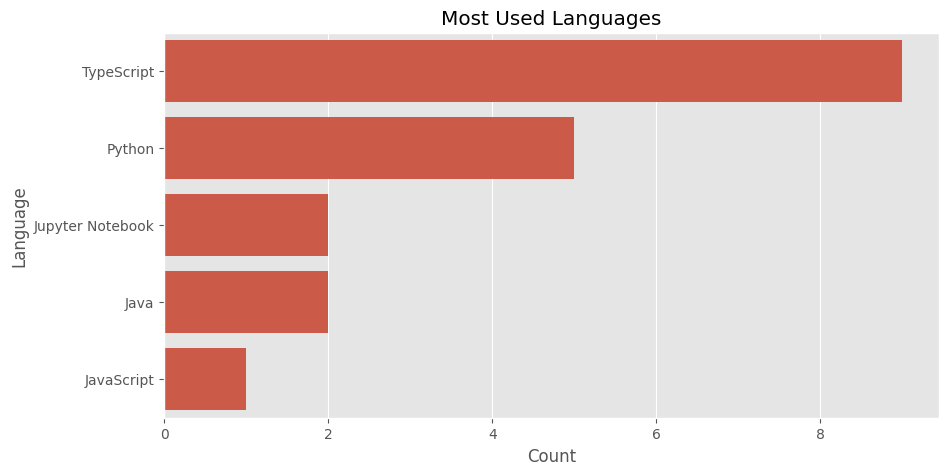

In [11]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="language",
    order=df["language"].value_counts().index
)

plt.title("Most Used Languages")
plt.xlabel("Count")
plt.ylabel("Language")

plt.show()

In [14]:
df["year"] = df["created_at"].dt.year

repo_growth = df["year"].value_counts().sort_index()

repo_growth

year
2025    14
2026    11
Name: count, dtype: int64

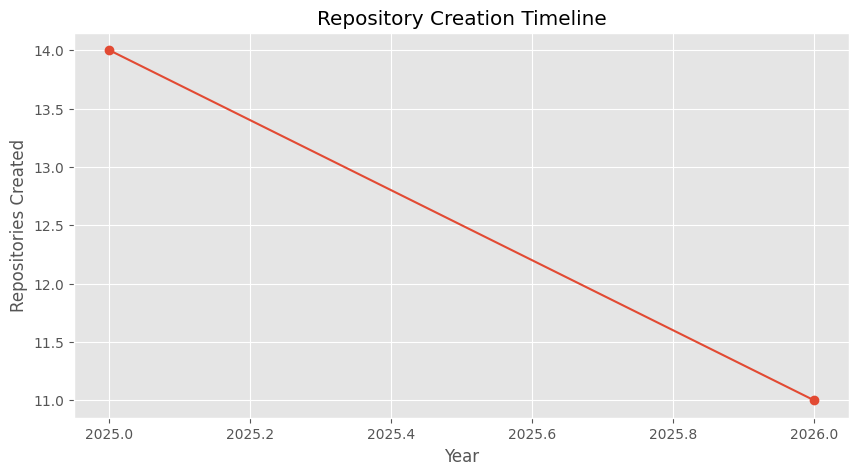

In [15]:
plt.figure(figsize=(10, 5))

repo_growth.plot(kind="line", marker="o")

plt.title("Repository Creation Timeline")
plt.xlabel("Year")
plt.ylabel("Repositories Created")

plt.show()

In [17]:
df["engagement_score"] = (
    df["stargazers_count"] +
    df["forks_count"] +
    df["watchers_count"]
)

df[[
    "name",
    "engagement_score"
]].sort_values(
    by="engagement_score",
    ascending=False
).head()

,name,engagement_score
12,monastery360,4
21,Talk2book,3
19,Python-Projects,2
4,cie-harmony-hub,2
2,AI-Data-Analyst,1
